
=== 모델 성능 비교 ===
                      RMSE       MAE  MAPE(%)
LinearRegression  23458.09  13189.91     2.87
Ridge (L2)        23509.66  13215.44     2.87
Lasso (L1)        23459.68  13190.36     2.87


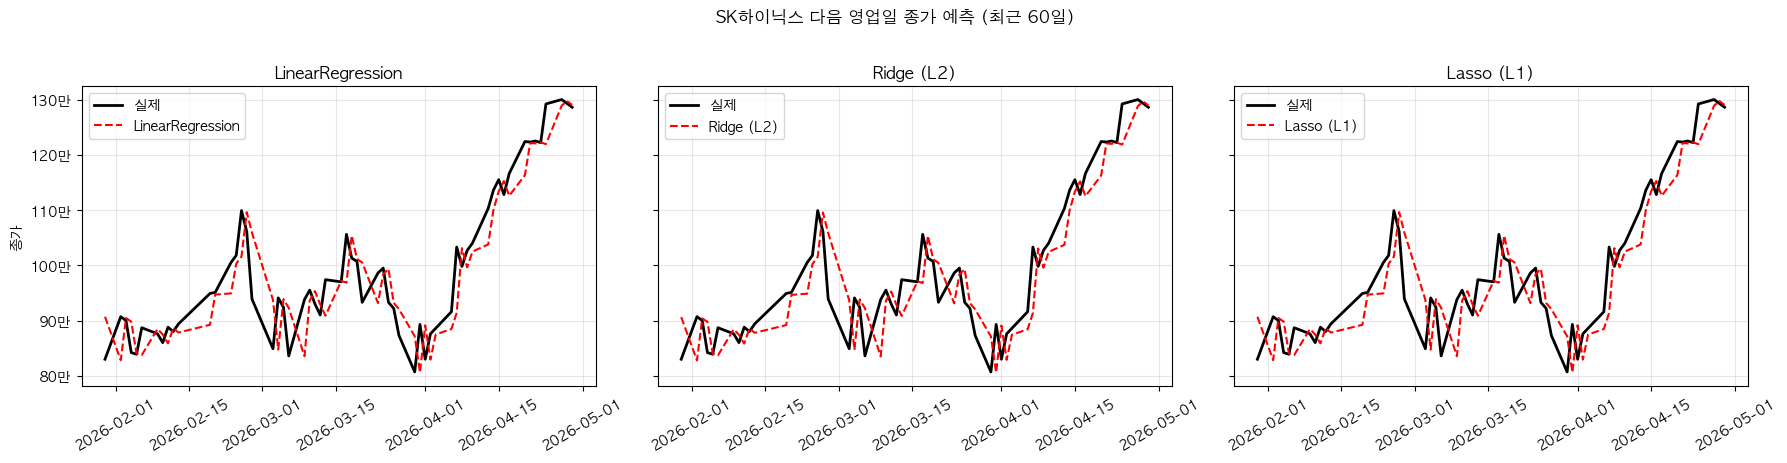


기준일: 2026-04-29  |  당일 종가: 1,293,000원
  LinearRegression  :  1,290,214원  (-0.22%)
  Ridge (L2)        :  1,289,441원  (-0.28%)
  Lasso (L1)        :  1,290,188원  (-0.22%)


In [1]:
"""
SK하이닉스(000660) 다음 영업일 종가 예측 - 선형 모델 3종 비교
   LinearRegression  vs  Ridge(L2)  vs  Lasso(L1)
"""

import warnings; warnings.filterwarnings("ignore")
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import FinanceDataReader as fdr

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 한글 폰트
plt.rcParams["font.family"] = "Malgun Gothic" if platform.system() == "Windows" else "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

# y축 표시 포맷: 만원 단위 (예: 1,300,000 → "130만")
won_fmt = FuncFormatter(lambda x, _: f"{x/10000:,.0f}만")


# ===== 1. 데이터 로드 =====
df = fdr.DataReader("000660", "2018-01-01").dropna()


# ===== 2. 피처 엔지니어링 =====
df["ret_1d"]  = df["Close"].pct_change(1)                                # 1일 수익률
df["ret_5d"]  = df["Close"].pct_change(5)                                # 5일 수익률
df["ma5_r"]   = df["Close"] / df["Close"].rolling(5).mean()  - 1         # 5일 이평선 대비
df["ma20_r"]  = df["Close"] / df["Close"].rolling(20).mean() - 1         # 20일 이평선 대비
df["vol_20d"] = df["ret_1d"].rolling(20).std()                           # 20일 변동성

# RSI(14)
delta = df["Close"].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
df["rsi"] = 100 - 100 / (1 + gain / (loss + 1e-9))

# 타깃: 다음 영업일 종가
df["target"] = df["Close"].shift(-1)
df = df.dropna()

features = ["Close", "ret_1d", "ret_5d", "ma5_r", "ma20_r", "vol_20d", "rsi"]
X = df[features]
y = df["target"]


# ===== 3. 시간 순서 보존 분할 (8:2) =====
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]


# ===== 4. 모델 정의 (스케일링 + 회귀) =====
models = {
    "LinearRegression": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge (L2)":       make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Lasso (L1)":       make_pipeline(StandardScaler(), Lasso(alpha=1.0)),
}


# ===== 5. 학습 & 평가 =====
results, preds = {}, {}
for name, model in models.items():
    model.fit(X_train, y_train)
    p = model.predict(X_test)
    preds[name]   = p
    results[name] = {
        "RMSE":    np.sqrt(mean_squared_error(y_test, p)),
        "MAE":     mean_absolute_error(y_test, p),
        "MAPE(%)": np.mean(np.abs((y_test - p) / y_test)) * 100,
    }

print("\n=== 모델 성능 비교 ===")
print(pd.DataFrame(results).T.round(2))


# ===== 6-1. 시각화: 모델별 서브플롯 (실제 vs 예측, 최근 60일) =====
N = 60
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)
for ax, (name, p) in zip(axes, preds.items()):
    ax.plot(y_test.index[-N:], y_test.values[-N:], "k-",  lw=2,   label="실제")
    ax.plot(y_test.index[-N:], p[-N:],             "r--", lw=1.5, label=name)
    ax.set_title(name); ax.legend(); ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=30)
    ax.yaxis.set_major_formatter(won_fmt)        # ← y축 만원 단위
axes[0].set_ylabel("종가")
plt.suptitle(f"SK하이닉스 다음 영업일 종가 예측 (최근 {N}일)", y=1.02)
plt.tight_layout()
plt.show()

# ===== 7. 다음 영업일 예측 =====
last_X     = X.iloc[[-1]]
last_close = df["Close"].iloc[-1]
last_date  = df.index[-1].date()

print(f"\n기준일: {last_date}  |  당일 종가: {last_close:,.0f}원")
for name, model in models.items():
    p   = model.predict(last_X)[0]
    chg = (p - last_close) / last_close * 100
    print(f"  {name:18s}: {p:>10,.0f}원  ({chg:+.2f}%)")

In [2]:
# end